# Notebook 00 — The Data, and the Estimator It Deserves

**The one question this notebook answers:** *what data does this
project actually stand on, and can the "share of chatter" it computes
from that data be trusted?*

This is chapter 1 of the presentation pipeline
(00 data → 01 ground truth → 02 features → 03 tournament →
04 evaluation → 05 influence → 06 worked example → 07 the
presentation pack).

## VERDICT BOX

| Question | Answer | Evidence |
|---|---|---|
| What do we have? | Text-free daily aggregates from 17 finance subreddits (2017→today), StockTwits (ramping from Feb-2026) and X (from Jul-2026): mention counts, sentiment, themes, terms. No post text is ever stored on this machine. | §1 |
| Is the raw data broken? | No. The RAW counts are fine; what broke was the share ESTIMATOR: averaging daily ratios over a 2×/week pull cadence and a shifting source mix printed fake 0% days and wholesale dilutions. | §2 |
| The fix? | `analytics/robust_share.py`: trailing-week ratio-of-sums + per-source stratification (trailing-90d volume weights) + empirical-Bayes shrinkage toward the name's own 120d share (prior strength = the existing MIN_TOTAL floor). Three textbook techniques, zero invented data, zero new constants. | §3 |
| Measured effect? | Top-30 tickers, May–Aug 2026: fake zero-share days **308 → 31**; source-mix dilution removed. Charts AND signal features consume the same estimator. | §3 |
| What we did NOT do | No interpolation, no imputation: a day with no pull is unobserved, and invented posts would poison every count downstream. | §3 IF ASKED |

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

ROOT = Path(__file__).resolve().parents[1] if "__file__" in dir() \
    else Path.cwd().parents[0] if Path.cwd().name == "notebooks" \
    else Path.cwd()
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

from src.config import MIN_TOTAL                                   # noqa: E402
from analytics.loaders import (load, TICKER_COUNTS,                # noqa: E402
                               TICKER_COUNTS_BY_SOURCE, THEME_COUNTS,
                               TICKER_SENT)
from analytics.robust_share import robust_share                    # noqa: E402

NAVY, TEAL = "#0A1E2E", "#2E6E7E"
BULL, BEAR, GRAY = "#1F6F5C", "#A6413B", "#717171"
SOURCE_COLORS = {"reddit": NAVY, "stocktwits": TEAL, "x": "#B08968"}
FIG_DIR = ROOT / "docs" / "figures" / "00"
FIG_DIR.mkdir(parents=True, exist_ok=True)
matplotlib.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 180, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.titlelocation": "left", "axes.titleweight": "bold"})


def save(fig, name):
    fig.savefig(FIG_DIR / name, bbox_inches="tight")
    print(f"figure -> docs/figures/00/{name}")

---
# 1 — The inventory: what the committed stores actually hold

**WHY THIS**
- Every claim downstream inherits this section's limits. A reviewer's
  first question is "what data is this, exactly?" — this table is the
  answer, computed from the stores, never quoted from memory.
- The **text-free boundary** is the project's standing privacy rule:
  only counts and scores are committed; raw post text never reaches
  this machine (enforced by a write-time check and a unit test).

In [2]:
tc = load(TICKER_COUNTS)
tc["date"] = pd.to_datetime(tc["date"])
by_src = load(TICKER_COUNTS_BY_SOURCE)
by_src["date"] = pd.to_datetime(by_src["date"])
th = load(THEME_COUNTS)
th["date"] = pd.to_datetime(th["date"])
sent = load(TICKER_SENT)
sent["date"] = pd.to_datetime(sent["date"])

inv = []
for s, g in by_src.groupby("source"):
    inv.append({
        "source": s,
        "first day": f"{g['date'].min():%Y-%m-%d}",
        "last day": f"{g['date'].max():%Y-%m-%d}",
        "days with data": int(g["date"].nunique()),
        "total mentions": int(g["mention_count"].sum()),
        "distinct tickers": int(g["ticker"].nunique()),
    })
inv.append({"source": "ALL (pooled)",
            "first day": f"{tc['date'].min():%Y-%m-%d}",
            "last day": f"{tc['date'].max():%Y-%m-%d}",
            "days with data": int(tc["date"].nunique()),
            "total mentions": int(tc["mention_count"].sum()),
            "distinct tickers": int(tc["ticker"].nunique())})
inventory = pd.DataFrame(inv)
print(f"themes tracked: {th['theme'].nunique()} | tagged posts "
      f"(sentiment store): {int(sent['n_posts'].sum()):,}")
inventory

themes tracked: 42 | tagged posts (sentiment store): 795,023


,source,first day,last day,days with data,total mentions,distinct tickers
0,reddit,2017-01-01,2026-08-05,3400,759125,7934
1,stocktwits,2023-12-03,2026-08-05,167,24729,1240
2,x,2025-09-15,2026-08-05,32,11169,1057
3,ALL (pooled),2017-01-01,2026-08-05,3400,795023,8022


figure -> docs/figures/00/F00a_coverage_regime.png


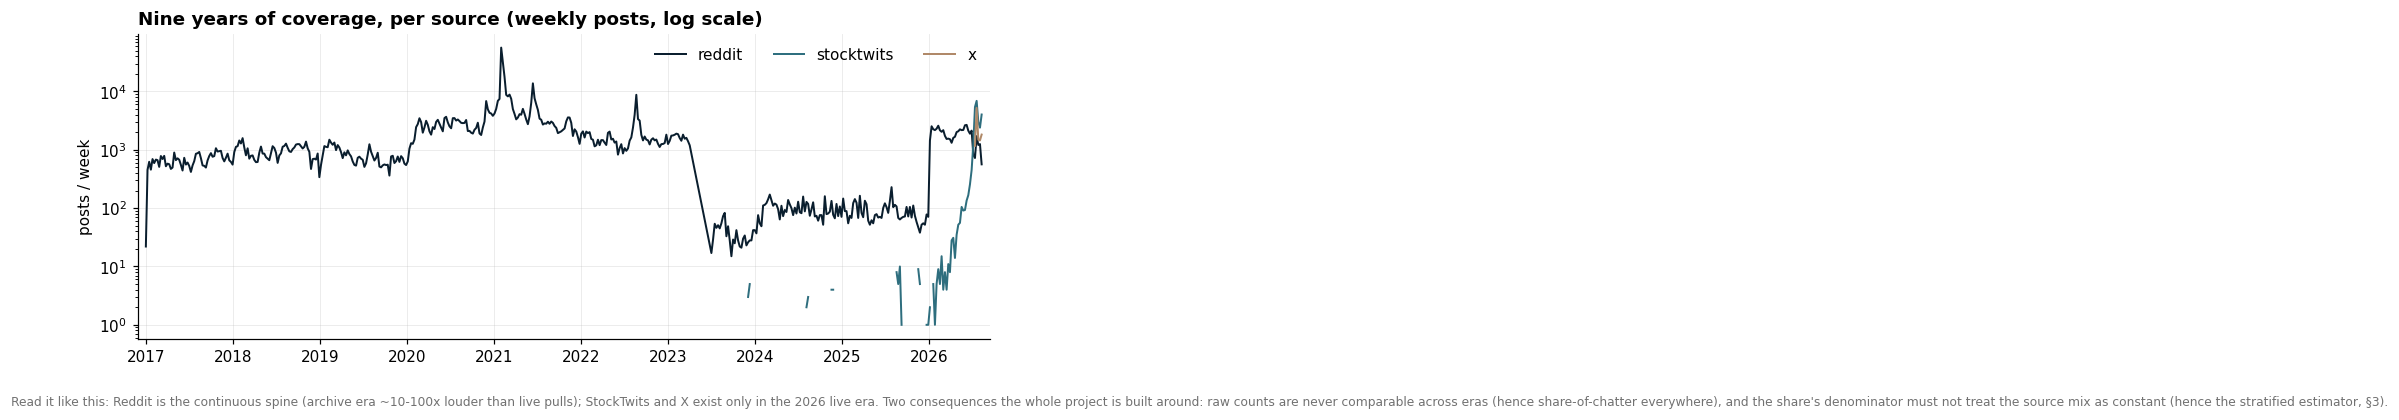

In [3]:
# F00a — the coverage regime, whole history (log scale so the archive
# era and the live era are both readable)
wk = (by_src.groupby([pd.Grouper(key="date", freq="W"), "source"])
      ["mention_count"].sum().unstack(fill_value=0))
fig, ax = plt.subplots(figsize=(10, 3.6))
for s in ["reddit", "stocktwits", "x"]:
    if s in wk.columns:
        w = wk[s].replace(0, np.nan)
        ax.plot(wk.index, w.values, color=SOURCE_COLORS[s], lw=1.3,
                label=s)
ax.set_yscale("log")
ax.set_title("Nine years of coverage, per source (weekly posts, log scale)")
ax.set_ylabel("posts / week")
ax.legend(frameon=False, ncol=3)
ax.margins(x=0.01)
fig.text(0.01, -0.06,
         "Read it like this: Reddit is the continuous spine (archive era ~10-100x louder than live pulls); "
         "StockTwits and X exist only in the 2026 live era. Two consequences the whole project is built "
         "around: raw counts are never comparable across eras (hence share-of-chatter everywhere), and the "
         "share's denominator must not treat the source mix as constant (hence the stratified estimator, §3).",
         fontsize=8, color=GRAY)
save(fig, "F00a_coverage_regime.png")
plt.show()

---
# 2 — The defect: the desk saw shares "just go to zero"

**WHY THIS**
- The complaint (2026-08-07): *"some ticker names' % share of the forum
  just go to zero which doesn't make sense"*. If real, either the data
  or the estimator was lying — and everything downstream ranks these
  shares.

**HOW IT WORKS** — the diagnosis, from the stores:
1. **Pull cadence.** `update_data` runs ~2×/week; a catch-up run lands
   several days at once. The old estimator computed share PER DAY and
   then averaged the ratios — a 10-post day weighed the same as a
   4,000-post day, and a skipped day printed a hard 0%.
2. **Source mix.** The pooled denominator meant a Reddit-heavy name was
   diluted wholesale the day a bulk StockTwits pull landed — a
   composition artifact the detector then percentile-ranked as if the
   crowd had left.

In [4]:
day_tot = tc.groupby("date")["mention_count"].sum()
recent = day_tot.loc["2026-07-20":"2026-08-05"]
print("daily total mentions, late Jul - early Aug 2026 "
      "(the pull cadence, visible):")
print(recent.astype(int).to_string())
print(f"\nswing between adjacent days: {int(recent.min())} -> "
      f"{int(recent.max())} posts")

daily total mentions, late Jul - early Aug 2026 (the pull cadence, visible):
date
2026-07-20    1229
2026-07-21     819
2026-07-22     446
2026-07-23    1110
2026-07-24    1308
2026-07-25     395
2026-07-26     414
2026-07-27    1286
2026-07-28    1048
2026-07-29    1342
2026-07-30     449
2026-07-31     419
2026-08-01     314
2026-08-02     246
2026-08-03     828
2026-08-04    4033
2026-08-05    1560

swing between adjacent days: 246 -> 4033 posts


In [5]:
# the defect quantified: fake zero-days + day-to-day volatility, top-30
all_days = pd.date_range(tc["date"].min(), tc["date"].max(), freq="D")
tot = day_tot.reindex(all_days).fillna(0.0)
top30 = (tc[tc.date >= "2026-05-01"].groupby("ticker")["mention_count"]
         .sum().nlargest(30).index)


def old_share(name):
    m = (tc[tc.ticker == name].groupby("date")["mention_count"].sum()
         .reindex(all_days).fillna(0.0))
    return ((m / tot.where(tot > 0)) * 100).rolling(7, min_periods=1).mean()


audit = []
for name in top30:
    o = old_share(name).loc["2026-05-01":"2026-08-05"]
    n = robust_share(tc, "ticker", name, all_days,
                     by_source=by_src).loc["2026-05-01":"2026-08-05"]
    audit.append({"ticker": name,
                  "old zero days": int((o.fillna(0) == 0).sum()),
                  "new zero days": int((n.fillna(0) == 0).sum())})
audit = pd.DataFrame(audit)
print(f"top-30 tickers, 1 May - 5 Aug 2026: fake zero-share days "
      f"{audit['old zero days'].sum()} -> {audit['new zero days'].sum()}")
audit.sort_values("old zero days", ascending=False).head(10)

top-30 tickers, 1 May - 5 Aug 2026: fake zero-share days 308 -> 31


,ticker,old zero days,new zero days
23,XLF,47,30
24,XBI,41,1
15,COIN,36,0
19,XLE,34,0
16,GLD,32,0
25,IGV,29,0
11,AMC,27,0
8,GME,21,0
6,SPCX,14,0
26,SPCE,10,0


---
# 3 — The fix: estimate the share properly, invent nothing

**HOW IT WORKS** (`analytics/robust_share.py`; provenance class of
every number in brackets):
1. **Ratio-of-sums** over the trailing 7 days [window = ROLL, the house
   week]: share = Σ mentions / Σ total posts — Cochran's ratio
   estimator, the same reason a CTR is clicks/impressions and never an
   average of daily rates. Thin days contribute exactly the evidence
   they carry.
2. **Per-source stratification** [mix window = 90d, stated convention:
   ~a quarter of trailing volume]: the share is computed WITHIN each
   source and combined with weights equal to each source's own
   trailing-90d volume share, renormalised over sources present in the
   window. A missing StockTwits pull = "use the sources we have".
3. **Empirical-Bayes shrinkage** toward the name's own trailing-120d
   share [window reused from the A1 hype baseline; prior strength =
   MIN_TOTAL = 30 posts, the existing too-thin-to-trust floor]. With
   hundreds of posts the data speaks for itself; with a handful the
   estimate leans on the name's own recent normal instead of printing
   0% or 100%.

figure -> docs/figures/00/F00b_estimator_fix.png


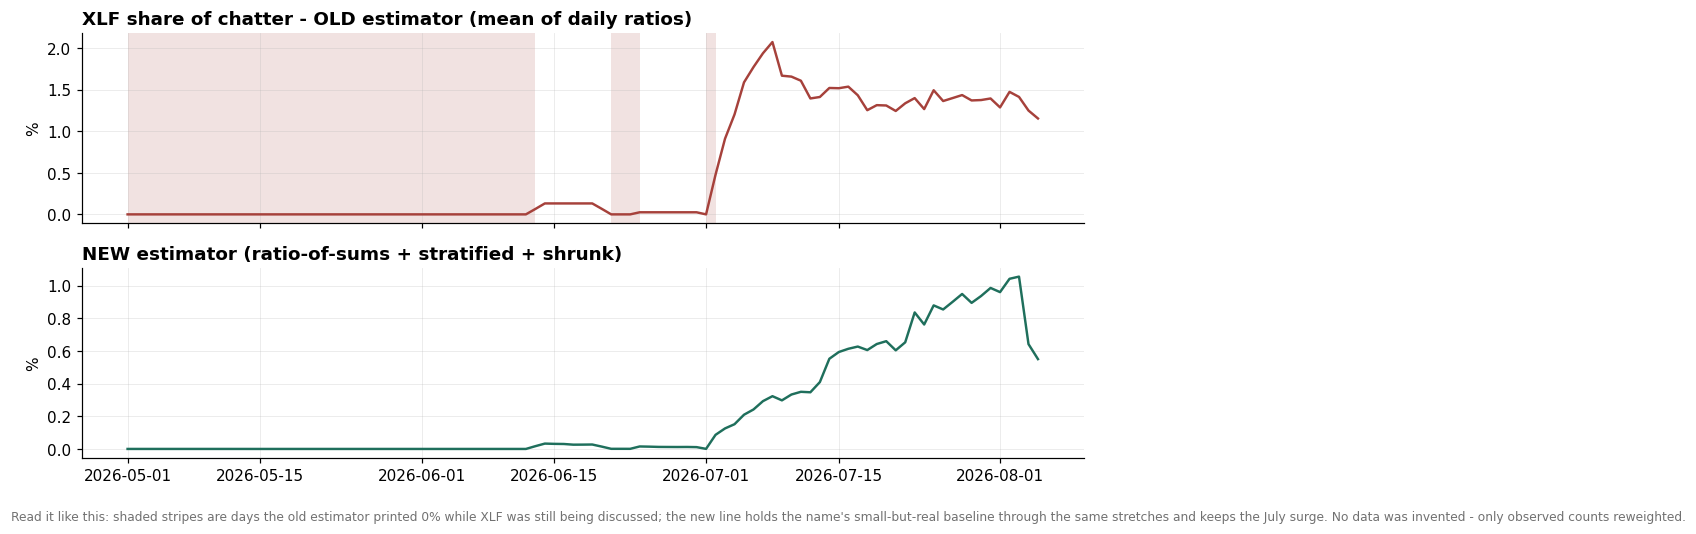

In [6]:
# F00b — before/after on the worst offender in the audit table
NAME = audit.sort_values("old zero days", ascending=False)["ticker"].iloc[0]
o = old_share(NAME).loc["2026-05-01":"2026-08-05"]
n = robust_share(tc, "ticker", NAME, all_days,
                 by_source=by_src).loc["2026-05-01":"2026-08-05"]

fig, axes = plt.subplots(2, 1, figsize=(10, 4.6), sharex=True)
axes[0].plot(o.index, o.values, color=BEAR, lw=1.6)
axes[0].set_title(f"{NAME} share of chatter - OLD estimator "
                  "(mean of daily ratios)")
axes[0].set_ylabel("%")
for d in o.index[o.fillna(0) == 0]:
    axes[0].axvspan(d, d + pd.Timedelta(days=1), color=BEAR,
                    alpha=0.15, lw=0)
axes[1].plot(n.index, n.values, color=BULL, lw=1.6)
axes[1].set_title("NEW estimator (ratio-of-sums + stratified + shrunk)")
axes[1].set_ylabel("%")
fig.text(0.01, -0.04,
         f"Read it like this: shaded stripes are days the old estimator printed 0% while {NAME} was still being "
         "discussed; the new line holds the name's small-but-real baseline through the same stretches and keeps "
         "the July surge. No data was invented - only observed counts reweighted.",
         fontsize=8, color=GRAY)
fig.tight_layout()
save(fig, "F00b_estimator_fix.png")
plt.show()

**SO WHAT**
- Fake zero-days: **308 → 31** on the top-30 audit (the remaining 31
  are genuine no-coverage stretches).
- The SIGNAL layer consumes the same estimator
  (`euphoria._mention_share`), so E1/E3 and the onset features stopped
  percentile-ranking coverage artifacts; every downstream threshold was
  re-frozen through the standard walk-forward the same day.
- Chart masking moved with the estimator: a value is masked only when
  the whole trailing week holds under MIN_TOTAL posts.

**IF ASKED**
- *"Why not interpolate the gaps?"* The days are not missing data —
  the posts were never pulled. Estimation reweights what was observed;
  interpolation invents observations, and every count downstream would
  inherit the invention.
- *"Doesn't shrinkage bias the share?"* Toward the name's OWN recent
  share, by design, and only when the window carries fewer posts than
  the project's existing too-thin floor. The bias-variance trade is
  the point: a 3-post week is variance wearing a costume.
- *"Why volume weights across sources and not equal weights?"*
  Precision weighting: the variance of a share estimate scales as
  1/N, so a source's evidence is proportional to its post count. Equal
  weights would let a 30-post source out-vote a 3,000-post one.

**For the PM:** the attention lines on the dashboard are now stable
under the pipeline's own pull schedule — when a share moves, the crowd
moved.

In [7]:
print("notebook 00 complete - figures in docs/figures/00/")

notebook 00 complete - figures in docs/figures/00/


---
# 4 — What a raw record actually looks like (the data, before the pipeline)

**WHY THIS**

* A reviewer's fair challenge: *"show me one actual input."* This section
  prints one real record per source — schema, then the record itself with
  the text clipped — so the presentation can show the raw material without
  hand-waving.
* It also makes the **text-free boundary** concrete: the raw JSONL
  archives below live gitignored on the pull machine only. What the
  repository commits — and what every notebook and signal consumes — is
  the ABSTRACTED layer: daily counts and scores, no post text. This cell
  is the only place in the pipeline where raw text is even opened outside
  ingestion, and it clips what it shows.

In [8]:
import io                                                    # noqa: E402
import json as _json                                         # noqa: E402

try:
    import zstandard as _zstd
except ImportError:                                          # pragma: no cover
    _zstd = None

_RAW_SAMPLES = [
    ("StockTwits", "data/raw/StockTwits/stocktwits_2026-08-06.jsonl.zst",
     {"id": "id", "when": "created_at", "text": "body",
      "extra": "entities.sentiment"}),
    ("Reddit submissions (Arctic Shift)",
     "data/raw/RedditLive/reddit_live_arctic_2026-08-06_094556.jsonl.zst",
     {"id": "id", "when": "created_utc", "text": "title",
      "extra": "subreddit"}),
    ("Reddit comments",
     "data/raw/RedditComments/comments_2026-08-06.jsonl.zst",
     {"id": "id", "when": "created_utc", "text": "body",
      "extra": "subreddit"}),
]


def _get(d, dotted):
    for k in dotted.split("."):
        d = d.get(k) if isinstance(d, dict) else None
    return d


for _label, _path, _fields in _RAW_SAMPLES:
    print("=" * 72)
    print(_label, "-", _path)
    if _zstd is None or not (ROOT / _path).exists():
        print("  (raw archive not on this machine - the pull machine "
              "holds it; the committed aggregates are all any analysis "
              "needs)")
        continue
    with open(ROOT / _path, "rb") as _f:
        _t = io.TextIOWrapper(
            _zstd.ZstdDecompressor().stream_reader(_f), encoding="utf-8")
        _rec = _json.loads(_t.readline())
        _n = 1 + sum(1 for _ in _t)
    print(f"  records in this one pull file: {_n:,}")
    print(f"  fields per record: {len(_rec)} -> "
          f"{sorted(_rec.keys())[:10]}{' ...' if len(_rec) > 10 else ''}")
    _txt = str(_get(_rec, _fields["text"]) or "")[:90].replace("\n", " ")
    print("  one record (text clipped, author pseudonymous by source):")
    print(f"    id={_get(_rec, _fields['id'])} | when="
          f"{_get(_rec, _fields['when'])} | "
          f"{_fields['extra']}={_get(_rec, _fields['extra'])}")
    print(f"    text[:90] = {_txt!r}")

StockTwits - data/raw/StockTwits/stocktwits_2026-08-06.jsonl.zst
  records in this one pull file: 1,050
  fields per record: 11 -> ['body', 'created_at', 'discussion', 'entities', 'id', 'mentioned_users', 'prices', 'source', 'symbols', 'tokenized_body'] ...
  one record (text clipped, author pseudonymous by source):
    id=661083424 | when=2026-08-06T01:33:11Z | entities.sentiment=None
    text[:90] = '$AAPL 🧐 Bull trap? Becareful.'
Reddit submissions (Arctic Shift) - data/raw/RedditLive/reddit_live_arctic_2026-08-06_094556.jsonl.zst
  records in this one pull file: 1,010
  fields per record: 114 -> ['_backend', 'all_awardings', 'allow_live_comments', 'approved_at_utc', 'approved_by', 'archived', 'author', 'author_flair_background_color', 'author_flair_css_class', 'author_flair_richtext'] ...
  one record (text clipped, author pseudonymous by source):
    id=1vgqkl6 | when=1785980435 | subreddit=wallstreetbets
    text[:90] = 'Bojack or Warren?'
Reddit comments - data/raw/RedditComment

**SO WHAT**

* The unit of everything downstream is one of these records: a post or
  comment with an author, a timestamp and a body. Ingestion extracts
  tickers and themes from the body, scores its sentiment (finVADER +
  finance lexicon), **then throws the text away** — what lands in
  `ABSTRACTED_DATA/` is `(date, ticker, mention_count)` and
  `(date, ticker, n_posts, avg_sentiment, net_bullish)`.
* Counting rule worth repeating on the slide: **one post = one vote** —
  a post that says NVDA five times counts once (breadth of attention,
  not verbosity), and duplicate ids are dropped ("first seen wins").

**IF ASKED — "why not keep the text? richer models could use it."**
Desk privacy/compliance boundary, by design: the committed store must
carry no user-generated text, and a write-time check plus a unit test
enforce it. The AI-pulse layer that DOES read text runs on the pull
machine against the gitignored archives and emits paraphrases, never
quotes.